In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
def extract_column_names(names_file):
    columns = ["class"]
    start = False

    with open(names_file, "r") as file:
        for line in file:
            line = line.strip()

            # Start after Attribute Information
            if "Attribute Information" in line:
                start = True
                continue

            if not start:
                continue

            # Only take lines that start with attribute numbers (1. to 22.)
            if line and line[0].isdigit():
                # Extract after "1. "
                parts = line.split(":", 1)
                if len(parts) > 1:
                    col_part = parts[0]  # "1. cap-shape"
                    col_name = col_part.split(".", 1)[1].strip()
                    columns.append(col_name)

            # Stop after 22 attributes
            if len(columns) == 23:
                break

    return columns

columns = extract_column_names("agaricus-lepiota.names")

print("Extracted Columns:")
for i, col in enumerate(columns):
    print(f"{i+1}. {col}")

print("\nTotal Columns:", len(columns))

Extracted Columns:
1. class
2. cap-shape
3. cap-surface
4. cap-color
5. bruises?
6. odor
7. gill-attachment
8. gill-spacing
9. gill-size
10. gill-color
11. stalk-shape
12. stalk-root
13. stalk-surface-above-ring
14. stalk-surface-below-ring
15. stalk-color-above-ring
16. stalk-color-below-ring
17. veil-type
18. veil-color
19. ring-number
20. ring-type
21. spore-print-color
22. population
23. habitat

Total Columns: 23


In [ ]:
df = pd.read_csv("agaricus-lepiota.data", header=None)

print("\nDataset Shape:", df.shape)

# Validate and assign headers
if len(columns) == df.shape[1]:
    df.columns = columns
    print("\nHeaders assigned successfully!\n")
else:
    raise ValueError("Column mismatch! Check header extraction.")

print(df.head())


Dataset Shape: (8124, 23)

Headers assigned successfully!

  class cap-shape cap-surface cap-color bruises? odor gill-attachment  \
0     p         x           s         n        t    p               f   
1     e         x           s         y        t    a               f   
2     e         b           s         w        t    l               f   
3     p         x           y         w        t    p               f   
4     e         x           s         g        f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0             

In [ ]:
df["class"] = df["class"].map({
    "e": "edible",
    "p": "poisonous"
})


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises?                  8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-co

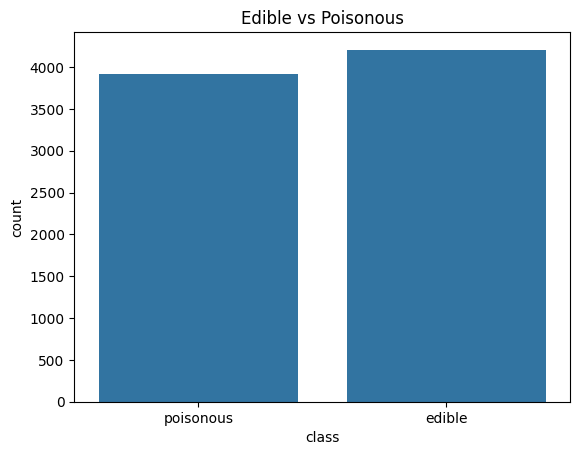

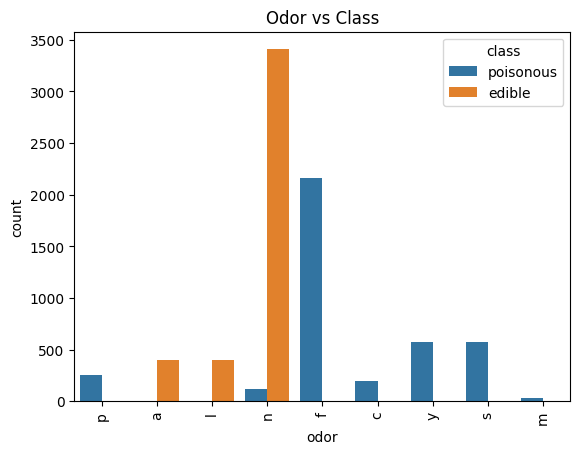

In [ ]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())

# Visualization
sns.countplot(x='class', data=df)
plt.title("Edible vs Poisonous")
plt.show()

sns.countplot(x='odor', hue='class', data=df)
plt.xticks(rotation=90)
plt.title("Odor vs Class")
plt.show()

In [ ]:
df.replace("?", np.nan, inplace=True)

print("\nMissing after replacement:\n", df.isnull().sum())

df.dropna(inplace=True)

# =========================================
# ENCODING
# =========================================
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

# =========================================
# FEATURE SCALING
# =========================================
X = df.drop("class", axis=1)
y = df["class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Missing after replacement:
 class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises?                       0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       705
           1       1.00      1.00      1.00       424

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129


Confusion Matrix:
 [[705   0]
 [  0 424]]


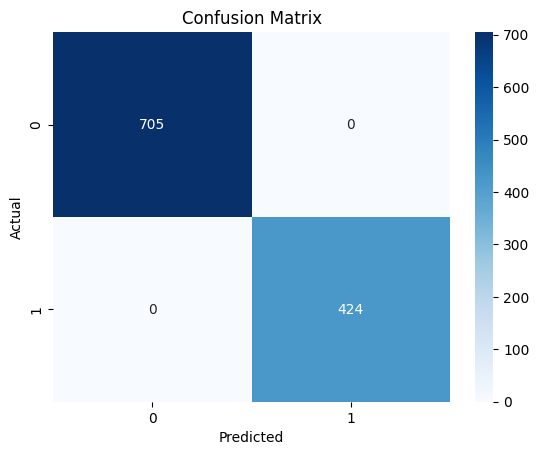

In [ ]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

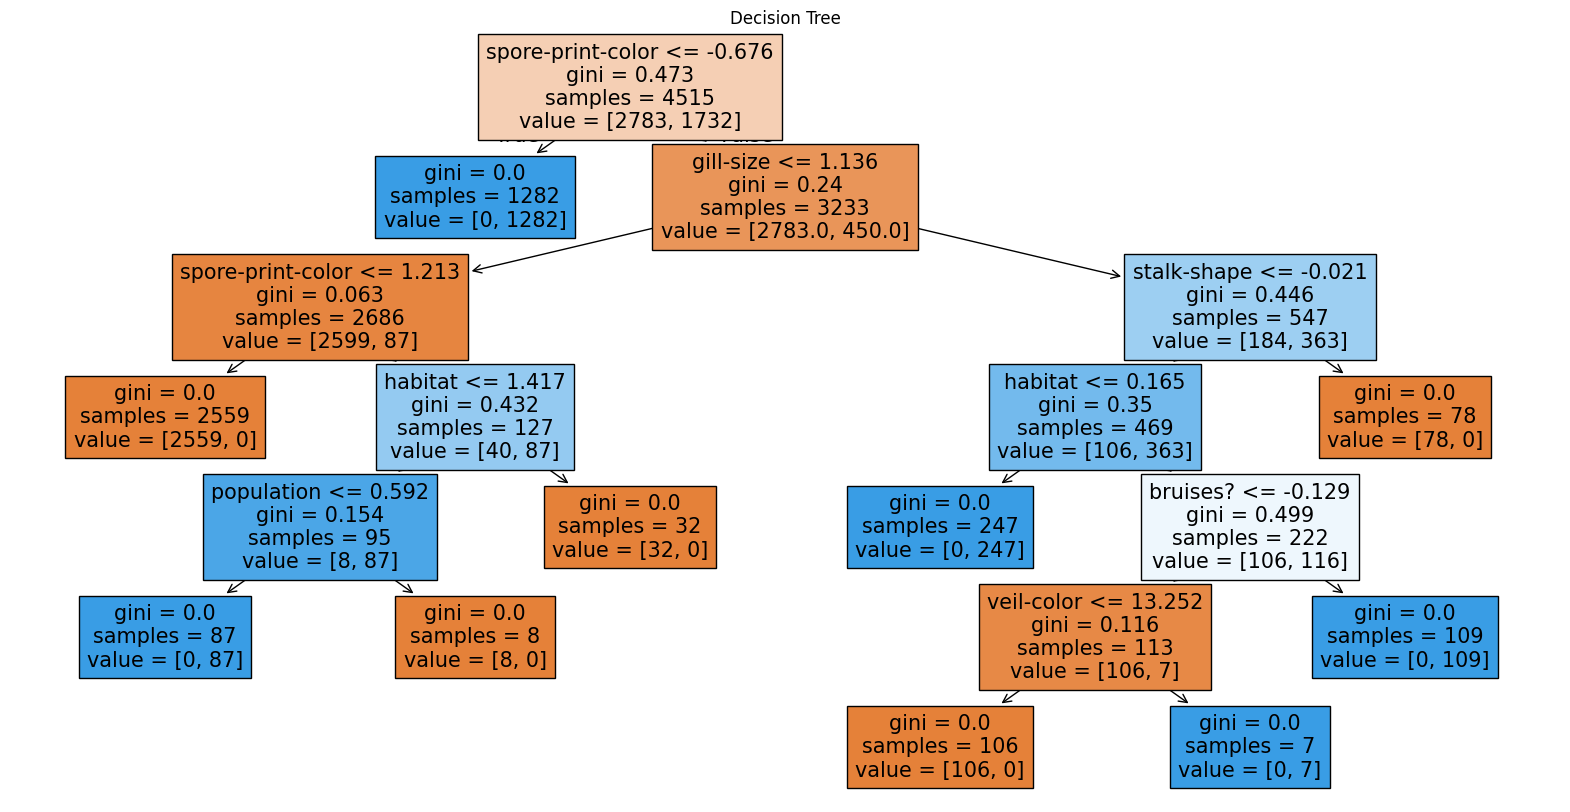

In [ ]:
# =========================================
# DECISION TREE VISUALIZATION
# =========================================
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.title("Decision Tree")
plt.show()

In [ ]:
results = []

for depth in [3, 5, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:

            clf = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )

            clf.fit(X_train, y_train)
            pred = clf.predict(X_test)
            acc = accuracy_score(y_test, pred)

            results.append([depth, split, leaf, acc])

results_df = pd.DataFrame(results, columns=[
    "max_depth", "min_samples_split", "min_samples_leaf", "accuracy"
])

print("\nHyperparameter Results:\n", results_df)

best = results_df.sort_values(by="accuracy", ascending=False).iloc[0]
print("\nBest Parameters:\n", best)


Hyperparameter Results:
     max_depth  min_samples_split  min_samples_leaf  accuracy
0           3                  2                 1  0.959256
1           3                  2                 2  0.959256
2           3                  2                 4  0.959256
3           3                  5                 1  0.959256
4           3                  5                 2  0.959256
5           3                  5                 4  0.959256
6           3                 10                 1  0.959256
7           3                 10                 2  0.959256
8           3                 10                 4  0.959256
9           5                  2                 1  0.999114
10          5                  2                 2  0.999114
11          5                  2                 4  0.999114
12          5                  5                 1  0.999114
13          5                  5                 2  0.999114
14          5                  5                 4  0.99911